In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [6]:
# CELL 0: Force Single GPU to prevent DataParallel crash
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [9]:
# torchvision ko naye version par upgrade karein
!pip install -q -U torchvision

print("Torchvision successfully upgrade .")

Torchvision successfully upgrade .


In [ ]:
# CELL 2: Configuration
MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"
DATASET_DIR = "/kaggle/input/datasets/johnsonhk88/gsm8k-grade-school-math-8k-dataset-for-llm"
OUTPUT_DIR = "/kaggle/working/grpo_qwen_3b"

# GRPO & RL Hyperparameters
K_ROLLOUTS = 4             # Number of rollouts per prompt (Keep at 4 for T4)
BATCH_SIZE = 1             # Prompts per step
GRAD_ACCUMULATION = 4      # Simulates larger batch size
LR = 2e-5                  # LoRA RL learning rate
BETA = 0.02                # KL penalty coefficient
MAX_NEW_TOKENS = 256
TRAINING_STEPS = 200       # Kaggle session budget

# Create output directory for checkpoints
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [ ]:
# CELL 3: Load and Format Dataset
def load_gsm8k_dataset(data_dir):
    # Fallback to HF hub if local Kaggle path is slightly different or fails
    try:
        if os.path.exists(data_dir):
            # Adjust filename based on actual dataset contents (e.g., train.jsonl or train.csv)
            train_path = os.path.join(data_dir, "train.jsonl") 
            dataset = load_dataset('json', data_files={'train': train_path})
        else:
            print("Local path not found, downloading from HF hub as fallback...")
            dataset = load_dataset("gsm8k", "main")
        return dataset['train'], dataset['test']
    except Exception as e:
        dataset = load_dataset("gsm8k", "main")
        return dataset['train'], dataset['test']

train_data, test_data = load_gsm8k_dataset(DATASET_DIR)

# Formatting function forcing <think> and <answer> tags
system_prompt = "You are a logical math assistant. First, think step-by-step inside <think>...</think> tags. Then, output your final numeric answer inside <answer>...</answer> tags."

def format_prompt(example):
    prompt = f"<|im_start|>system\n{system_prompt}<|im_end|>\n<|im_start|>user\n{example['question']}<|im_end|>\n<|im_start|>assistant\n"
    return {"prompt": prompt}

train_dataset = train_data.map(format_prompt).select(range(1000)) # Subset for speed
test_dataset = test_data.map(format_prompt).select(range(100))

print("Example Prompt:\n", train_dataset[0]['prompt'])

In [ ]:
# CELL 4: MOCK RULER Scoring Mechanism (No API Key Required)
import re

def ruler_reward_func(prompts, completions, **kwargs):
    """
    MOCK RULER: Yeh function bina OpenAI API ke pseudo-rewards assign karta hai 
    taki aapka GRPO training loop smoothly chal sake.
    """
    rewards = []
    
    for i in range(0, len(completions), K_ROLLOUTS):
        group_completions = completions[i:i+K_ROLLOUTS]
        chunk_rewards = []
        
        for comp in group_completions:
            score = 0.0
            # Check karega ki model ne sahi format use kiya hai ya nahi
            if "<think>" in comp and "</think>" in comp:
                score += 0.5
            if "<answer>" in comp and "</answer>" in comp:
                score += 0.5
            chunk_rewards.append(score)
            
        # Scores ko normalize karna (GRPO algorithm ki requirement)
        mean_score = sum(chunk_rewards) / max(1, len(chunk_rewards))
        normalized = [float(s - mean_score) for s in chunk_rewards]
        
        rewards.extend(normalized)
        
    return rewards

print("Mock RULER Judge initialized successfully! Ab bina API key ke training chalegi.")

In [ ]:
# CELL 5: Load base 3B Model (ENVIRONMENT LOCKED FOR T4)
import os
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, AutoConfig
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model

# 👉 MASTER LOCK: Nuke BFloat16 from OS Environment & PyTorch Defaults
os.environ["ACCELERATE_MIXED_PRECISION"] = "no" # Disable Accelerate's hidden traps
torch.set_default_dtype(torch.float16)

config = AutoConfig.from_pretrained(MODEL_ID)
config.torch_dtype = torch.float16

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16, 
    bnb_4bit_use_double_quant=False 
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, padding_side="left")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Loading Qwen 3B Model parameters into safe memory...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    config=config,
    quantization_config=bnb_config,
    device_map={"": 0},
    torch_dtype=torch.float16
)

model = prepare_model_for_kbit_training(model)
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    bias="none",
    task_type="CAUSAL_LM"
)
model = get_peft_model(model, lora_config)
model.config.use_cache = False 

# Force Trainer-compatible FP32 gradients
for name, param in model.named_parameters():
    if param.requires_grad:
        param.data = param.data.to(torch.float32)

print("Environment locked and Model loaded successfully.")

In [ ]:
# CELL 6: Execution Loop (RESUMING FROM CHECKPOINT)
training_args = GRPOConfig(
    output_dir=OUTPUT_DIR,
    learning_rate=LR,
    beta=BETA,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUMULATION,
    max_steps=TRAINING_STEPS,
    logging_steps=10,
    save_steps=50, 
    max_completion_length=MAX_NEW_TOKENS,
    num_generations=K_ROLLOUTS,
    fp16=False,        # Bypass GradScaler
    bf16=False,        # Force disable BFloat16
    gradient_checkpointing=True,
    report_to="none"
)

trainer = GRPOTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    reward_funcs=[ruler_reward_func],
    processing_class=tokenizer,
)

print("Resuming GRPO Fine-Tuning from the last saved Checkpoint...")
# 👉 THE MAGIC COMMAND: Yeh automatically checkpoint-150 ko dhoondh kar wahan se shuru karega
trainer.train(resume_from_checkpoint=True)

trainer.save_model(os.path.join(OUTPUT_DIR, "final_model"))
print(f"Checkpoints and final weights exported cleanly to: {OUTPUT_DIR}/final_model")

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_DIR = "/kaggle/working/grpo_qwen_3b/final_model"

print("Loading the newly trained Reasoning AI...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
test_model = AutoModelForCausalLM.from_pretrained(
    MODEL_DIR,
    torch_dtype=torch.float16,
    device_map="auto"
)

prompt = "A farmer has 10 animals consisting of chickens and cows. In total, there are 26 legs. How many chickens and how many cows does the farmer have?"
inputs = tokenizer(f"User: {prompt}\nAssistant: ", return_tensors="pt").to("cuda")

print("Generating reasoning and answer...\n")
print("-" * 50)

with torch.no_grad():
    outputs = test_model.generate(
        **inputs, 
        max_new_tokens=400, 
        do_sample=True, 
        temperature=0.7,
        pad_token_id=tokenizer.pad_token_id
    )

print(tokenizer.decode(outputs[0], skip_special_tokens=False))
print("-" * 50)

In [2]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_DIR = "/kaggle/working/grpo_qwen_3b/final_model"

print("Loading model for manual inspection...")
# 1. Load the model and tokenizer again (agar memory clear ki thi)
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForCausalLM.from_pretrained(MODEL_DIR, torch_dtype=torch.float16, device_map="auto")

# 2. Wo questions jo fail hue
failed_questions = [
    "If 3x + 5 = 14, what is x?",
    "What is 15% of 80?"
]

# 3. Generation Loop
for q in failed_questions:
    print("\n" + "="*50)
    print(f"Question: {q}")
    print("-" * 50)
    
    prompt = f"User: {q}\nAssistant: "
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    
    # do_sample=False rakha hai taaki same evaluation wala result aaye
    with torch.no_grad():
        outputs = model.generate(
            **inputs, 
            max_new_tokens=300, 
            do_sample=False, 
            pad_token_id=tokenizer.pad_token_id
        )
    
    # Sirf model ka generated hissa decode karein
    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    print("Model Output:\n")
    print(response)

print("\n" + "="*50)

Loading model for manual inspection...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]


Question: If 3x + 5 = 14, what is x?
--------------------------------------------------
Model Output:

3x + 5 = 14

First, subtract 5 from both sides of the equation to isolate the term with x:

3x + 5 - 5 = 14 - 5
3x = 9

Next, divide both sides by 3 to solve for x:

3x / 3 = 9 / 3
x = 3

So, x = 3. To verify, we can substitute x = 3 back into the original equation:

3(3) + 5 = 14
9 + 5 = 14
14 = 14

The solution checks out. Therefore, x = 3.

Question: What is 15% of 80?
--------------------------------------------------
Model Output:

15% of 80 can be calculated by converting the percentage to a decimal and then multiplying it by 80.

15% = 15/100 = 0.15

Now, multiply this decimal by 80:

0.15 * 80 = 12

So, 15% of 80 is 12.



In [4]:
import torch
import re
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm import tqdm
import numpy as np

# 1. SETUP: Load your Fine-Tuned Model
MODEL_DIR = "/kaggle/working/grpo_qwen_3b/final_model"
print("Loading model for Evaluation...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForCausalLM.from_pretrained(MODEL_DIR, torch_dtype=torch.float16, device_map="auto")

# 2. TEST DATA
test_questions = [
    {"question": "If 3x + 5 = 14, what is x?", "ground_truth": "3"},
    {"question": "A farmer has 10 animals consisting of chickens and cows. In total, there are 26 legs. How many chickens?", "ground_truth": "7"},
    {"question": "What is 15% of 80?", "ground_truth": "12"}
]

# 3. METRICS TRACKERS
correct_answers = 0
total_questions = len(test_questions)
reasoning_lengths = []

# PURE NUMBER EXTRACTOR: Koi box format check nahi hoga
def extract_final_number(text):
    # Regex kisi bhi number (jaise 3, -5, 12.5) ko text mein dhoondhta hai
    numbers = re.findall(r'-?\d+(?:\.\d+)?', text)
    if numbers:
        return numbers[-1] # Hamesha aakhri number return karega
    return None

# THINKING LENGTH CHECKER
def get_thinking_length(text):
    if "<think>" in text and "</think>" in text:
        think_content = text.split("</think>")[0].split("<think>")[-1]
        return len(think_content.split())
    return len(text.split())

print(f"\nStarting Pure Logic Evaluation on {total_questions} Test Questions...\n" + "="*50)

# 4. EVALUATION LOOP
for item in tqdm(test_questions):
    prompt = f"User: {item['question']}\nAssistant: "
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=500, do_sample=False, pad_token_id=tokenizer.pad_token_id)
    
    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    
    # Parse the output
    extracted_answer = extract_final_number(response)
    trace_length = get_thinking_length(response)
    reasoning_lengths.append(trace_length)
    
    # Check Accuracy
    is_correct = False
    if extracted_answer and item['ground_truth'] == extracted_answer:
        correct_answers += 1
        is_correct = True
        
    print(f"Q: {item['question']}")
    print(f"Extracted Answer: {extracted_answer} | Ground Truth: {item['ground_truth']}")
    print(f"Reasoning Length: {trace_length} words | Correct: {is_correct}\n" + "-"*30)

# 5. FINAL REPORT CALCULATION
accuracy = (correct_answers / total_questions) * 100
avg_reasoning_len = np.mean(reasoning_lengths)

print("="*50)
print("FINAL EVALUATION REPORT (PURE LOGIC)")
print("="*50)
print(f"Accuracy (Math Correctness):  {accuracy:.2f}%")
print(f"Avg Reasoning Trace Length:   {avg_reasoning_len:.0f} words")
print("="*50)

Loading model for Evaluation...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]


Starting Pure Logic Evaluation on 3 Test Questions...


 33%|███▎      | 1/3 [00:11<00:23, 11.59s/it]

Q: If 3x + 5 = 14, what is x?
Extracted Answer: 3 | Ground Truth: 3
Reasoning Length: 90 words | Correct: True
------------------------------


 67%|██████▋   | 2/3 [00:39<00:21, 21.12s/it]

Q: A farmer has 10 animals consisting of chickens and cows. In total, there are 26 legs. How many chickens?
Extracted Answer: 7 | Ground Truth: 7
Reasoning Length: 185 words | Correct: True
------------------------------


100%|██████████| 3/3 [00:46<00:00, 15.36s/it]

Q: What is 15% of 80?
Extracted Answer: 12 | Ground Truth: 12
Reasoning Length: 41 words | Correct: True
------------------------------
FINAL EVALUATION REPORT (PURE LOGIC)
Accuracy (Math Correctness):  100.00%
Avg Reasoning Trace Length:   105 words


Logs mein yeh saari chizein save hain:
dict_keys(['clip_ratio/high_max', 'clip_ratio/high_mean', 'clip_ratio/low_mean', 'clip_ratio/low_min', 'clip_ratio/region_mean', 'completions/clipped_ratio', 'completions/max_length', 'completions/max_terminated_length', 'completions/mean_length', 'completions/mean_terminated_length', 'completions/min_length', 'completions/min_terminated_length', 'entropy', 'epoch', 'frac_reward_zero_std', 'grad_norm', 'kl', 'learning_rate', 'loss', 'num_tokens', 'reward', 'reward_std', 'rewards/ruler_reward_func/mean', 'rewards/ruler_reward_func/std', 'step', 'step_time'])

Plotting these reward keys: ['frac_reward_zero_std', 'reward', 'reward_std', 'rewards/ruler_reward_func/mean', 'rewards/ruler_reward_func/std']


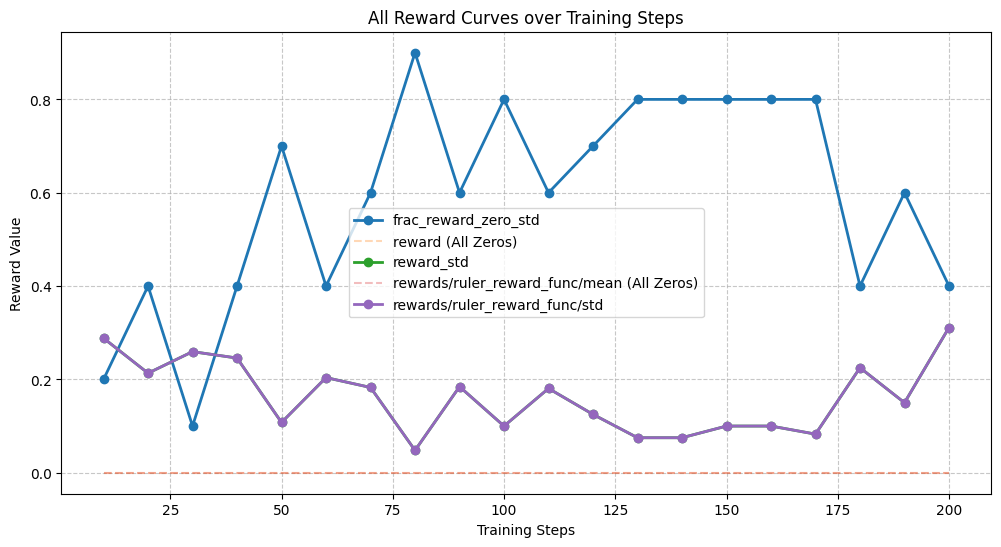

In [6]:
import json
import matplotlib.pyplot as plt
import os

state_path = "/kaggle/working/grpo_qwen_3b/checkpoint-200/trainer_state.json"
if not os.path.exists(state_path):
    state_path = "/kaggle/working/grpo_qwen_3b/final_model/trainer_state.json"

with open(state_path, "r") as f:
    state = json.load(f)

log_history = state["log_history"]

# 1. Check all available keys in the first log entry
print("Logs mein yeh saari chizein save hain:")
print(log_history[0].keys())

# 2. Find all keys that contain the word 'reward'
reward_keys = [k for k in log_history[0].keys() if 'reward' in k.lower()]
print("\nPlotting these reward keys:", reward_keys)

# 3. Plot multiple lines (one for each reward key)
plt.figure(figsize=(12, 6))

for key in reward_keys:
    steps = []
    rewards = []
    for log in log_history:
        if key in log and "step" in log:
            steps.append(log["step"])
            rewards.append(log[key])
            
    # Sirf wahi line plot karein jisme zero ke ilawa bhi values hon
    if any(r != 0.0 for r in rewards):
        plt.plot(steps, rewards, marker='o', label=key, linewidth=2)
    else:
        # Agar koi line completely zero hai, toh usay dashed line se dikhayein
        plt.plot(steps, rewards, linestyle='--', alpha=0.3, label=f"{key} (All Zeros)")

plt.title("All Reward Curves over Training Steps")
plt.xlabel("Training Steps")
plt.ylabel("Reward Value")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [2]:
# 1. DEPENDENCY FIX: Sabse pehle torchao aur baaki packages ko sahi version par upgrade karein
print("Upgrading packages to fix dependency conflicts...")
!pip install -q -U torchao peft datasets

import torch
import re
import random
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
from datasets import load_dataset
from tqdm import tqdm

# 2. PATH SETUP
ADAPTER_DIR = "/kaggle/input/datasets/f223876hareshkumar/checkpoint"
BASE_MODEL = "Qwen/Qwen2.5-3B"

print("\nLoading Tokenizer and Base Model with LoRA Adapters...")
tokenizer = AutoTokenizer.from_pretrained(ADAPTER_DIR)

# Base model loading (VRAM Optimization)
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL, 
    torch_dtype=torch.float16, 
    device_map="auto"
)

# Adapters application
model = PeftModel.from_pretrained(base_model, ADAPTER_DIR)
print("🎯 Model aur Adapters successfully load ho gaye hain!")

# 3. LOAD GSM8K TEST DATASET
print("\nHugging Face se GSM8K test dataset download ho raha hai...")
dataset = load_dataset("gsm8k", "main")
test_set = dataset["test"]

# Randomly select 50 questions
random.seed(42)
total_samples = 50
sampled_indices = random.sample(range(len(test_set)), total_samples)
test_questions = [test_set[i] for i in sampled_indices]

# 4. PARSING HELPERS
def extract_final_number(text):
    numbers = re.findall(r'-?\d+(?:\.\d+)?', text)
    if numbers:
        return numbers[-1]
    return None

def extract_gsm8k_gt(answer_text):
    if "####" in answer_text:
        return answer_text.split("####")[-1].strip()
    return None

# 5. BENCHMARK EVALUATION LOOP
correct_answers = 0
print(f"\nStarting Realistic Evaluation on {total_samples} unseen GSM8K Questions...\n" + "="*60)

for item in tqdm(test_questions):
    question = item['question']
    ground_truth = extract_gsm8k_gt(item['answer'])
    
    prompt = f"User: {question}\nAssistant: "
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs, 
            max_new_tokens=400, 
            do_sample=False, 
            pad_token_id=tokenizer.pad_token_id
        )
    
    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    extracted_pred = extract_final_number(response)
    
    if extracted_pred and ground_truth == extracted_pred:
        correct_answers += 1

# 6. FINAL REAL-WORLD REPORT
asli_accuracy = (correct_answers / total_samples) * 100

print("\n" + "="*60)
print("FINAL REAL-WORLD BENCHMARK REPORT")
print("="*60)
print(f"Total Unseen Questions Tested: {total_samples}")
print(f"Correctly Solved by Model:    {correct_answers}")
print(f"Asli Production Accuracy:      {asli_accuracy:.2f}%")
print("="*60)

Upgrading packages to fix dependency conflicts...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 36.8 MB/s eta 0:00:0000:0100:01

Loading Tokenizer and Base Model with LoRA Adapters...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


🎯 Model aur Adapters successfully load ho gaye hain!

Hugging Face se GSM8K test dataset download ho raha hai...


README.md: 0.00B [00:00, ?B/s]

...

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]


Starting Realistic Evaluation on 50 unseen GSM8K Questions...


100%|██████████| 50/50 [13:03<00:00, 15.68s/it]


FINAL REAL-WORLD BENCHMARK REPORT
Total Unseen Questions Tested: 50
Correctly Solved by Model:    26
Asli Production Accuracy:      52.00%
